In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [201]:
#Load CSV and display first 5 rows
df = pd.read_csv('/Users/nathan/Downloads/trending_US_7d_20260305-1400.csv')
df.head(7)

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
0,kristi noem,2M+,"March 3, 2026 at 6:30:00 AM UTC-8",NaN,"kristi noem,markwayne mullin,noem,kristi noem ...",./explore?q=kristi%20noem&geo=US
1,iran war,5M+,"February 27, 2026 at 7:10:00 PM UTC-8",NaN,"iran war,israel,war,iran war news,iran,iran ne...",./explore?q=iran%20war&geo=US
2,scary movie 6,1M+,"February 26, 2026 at 4:50:00 PM UTC-8",NaN,"scary movie 6,scary movie,scary movie 6 traile...",./explore?q=scary%20movie%206&geo=US
3,jim carrey,2M+,"February 26, 2026 at 7:50:00 PM UTC-8",NaN,"jim carrey,jim carrey new face,jim carrey 2026...",./explore?q=jim%20carrey&geo=US
4,macbook neo,1M+,"March 3, 2026 at 8:00:00 AM UTC-8",NaN,"macbook neo,apple,macbook,apple macbook neo,ma...",./explore?q=macbook%20neo&geo=US
5,is amazon down,200K+,"March 5, 2026 at 11:00:00 AM UTC-8",NaN,"is amazon down,amazon,is amazon down right now...",./explore?q=is%20amazon%20down&geo=US
6,dubai,500K+,"February 28, 2026 at 12:40:00 AM UTC-8",NaN,"dubai,doha,flight radar,etihad,british airways...",./explore?q=dubai&geo=US


In [202]:
#Convert search volume to numeric values
df['Search volume'] = df['Search volume'].astype(str)
df['Search volume'] = df['Search volume'].str.replace('K+,', '000')
df['Search volume'] = df['Search volume'].str.replace('M+', '000000')
df['Search volume'] = df['Search volume'].str.replace('B+', '000000000')
df['Search volume'] = df['Search volume'].str.replace('+', '')
df['Search volume'] = df['Search volume'].str.replace('K', '000')
df['Search volume'] = df['Search volume'].str.replace('M', '000000')
df['Search volume'] = pd.to_numeric(df['Search volume'], errors='coerce')
df.head(7)

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
0,kristi noem,2000000,"March 3, 2026 at 6:30:00 AM UTC-8",NaN,"kristi noem,markwayne mullin,noem,kristi noem ...",./explore?q=kristi%20noem&geo=US
1,iran war,5000000,"February 27, 2026 at 7:10:00 PM UTC-8",NaN,"iran war,israel,war,iran war news,iran,iran ne...",./explore?q=iran%20war&geo=US
2,scary movie 6,1000000,"February 26, 2026 at 4:50:00 PM UTC-8",NaN,"scary movie 6,scary movie,scary movie 6 traile...",./explore?q=scary%20movie%206&geo=US
3,jim carrey,2000000,"February 26, 2026 at 7:50:00 PM UTC-8",NaN,"jim carrey,jim carrey new face,jim carrey 2026...",./explore?q=jim%20carrey&geo=US
4,macbook neo,1000000,"March 3, 2026 at 8:00:00 AM UTC-8",NaN,"macbook neo,apple,macbook,apple macbook neo,ma...",./explore?q=macbook%20neo&geo=US
5,is amazon down,200000,"March 5, 2026 at 11:00:00 AM UTC-8",NaN,"is amazon down,amazon,is amazon down right now...",./explore?q=is%20amazon%20down&geo=US
6,dubai,500000,"February 28, 2026 at 12:40:00 AM UTC-8",NaN,"dubai,doha,flight radar,etihad,british airways...",./explore?q=dubai&geo=US


In [203]:
#Group searches by general category
df.sort_values(by='Search volume', ascending=False).head(10)
iran_values = sum(df['Trend breakdown'].str.contains('iran'))


In [213]:
from collections import Counter
from itertools import chain

sorted_word_counts = dict(
    sorted(
        Counter(chain.from_iterable(df['Trend breakdown'].apply(lambda s: [w for p in s.split(',') for w in p.strip().split()])))
        .items(),
        key=lambda x: x[1],
        reverse=True
    )
)
print(sorted_word_counts)
#remove stop words
most_words = pd.DataFrame(list(sorted_word_counts.items()), columns=['Word', 'Count'])
most_words = most_words[most_words['Word'].isin(['...', '-', 'is', 'in', 'did', 'of', 'and', 'the', 'to', 'where']) == False]
most_words.sort_values(by='Count', ascending=False).head(20)

{'vs': 622, 'basketball': 242, 'iran': 204, 'is': 193, '2026': 149, 'the': 145, '-': 105, 'to': 101, 'today': 97, 'texas': 94, 'us': 92, 'where': 83, 'moon': 78, 'state': 78, 'news': 76, 'noem': 73, 'watch': 73, 'of': 69, 'stock': 66, 'what': 62, 'in': 58, 'war': 56, 'did': 55, 'eclipse': 55, 'time': 53, 'cricket': 51, 'who': 49, 'and': 49, 'fc': 48, 'tonight': 48, 'team': 46, 'city': 46, 'madrid': 46, 'trump': 45, 'new': 45, 'results': 45, 'kristi': 43, 'austin': 42, 'game': 40, 'barcelona': 40, 'lakers': 40, 'leader': 39, 'shooting': 39, 'real': 39, 'israel': 37, 'down': 37, 'blood': 37, 'amazon': 36, 'lunar': 36, 'blue': 36, 'why': 35, 'on': 35, 'attack': 35, 'pokemon': 34, 'live': 34, 'primary': 34, 'standings': 33, 'national': 32, 'election': 31, 'f.c.': 30, 'match': 30, 'when': 30, 'season': 30, 'khamenei': 30, 'knicks': 30, 'united': 29, 'india': 29, "women's": 29, 'nuggets': 29, 'alert': 29, 'schedule': 28, 'stats': 28, 'snl': 28, 'dubai': 27, 'dead': 26, 'celtics': 26, 'arsena

,Word,Count
0,vs,622
1,basketball,242
2,iran,204
4,2026,149
8,today,97
9,texas,94
10,us,92
12,moon,78
13,state,78
14,news,76


<BarContainer object of 10 artists>

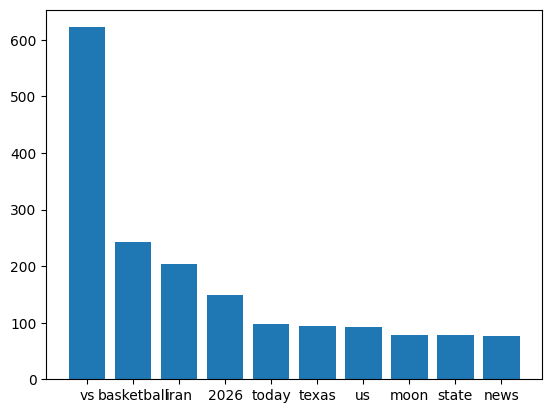

In [205]:
#plot most popular keywords
plt.bar(x= most_words['Word'][:10], height=most_words['Count'][:10])

In [206]:
#see what each keyword is about
(df[df['Trend breakdown'].str.contains('vs', na=False)]).sample(3)

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
1351,yale basketball,5000,"February 27, 2026 at 3:00:00 PM UTC-8","February 27, 2026 at 6:00:00 PM UTC-8","yale basketball,yale vs cornell,cornell basket...",./explore?q=yale%20basketball&geo=US
496,spurs vs nets,20000,"February 26, 2026 at 3:10:00 PM UTC-8","February 27, 2026 at 5:40:00 AM UTC-8","spurs vs nets,julian champagnie,where to watch...",./explore?q=spurs%20vs%20nets&geo=US
533,mi state vs purdue,50000,"February 26, 2026 at 4:20:00 PM UTC-8","February 27, 2026 at 6:20:00 AM UTC-8","mi state vs purdue,purdue basketball,michigan ...",./explore?q=mi%20state%20vs%20purdue&geo=US


In [207]:
(df[df['Trend breakdown'].str.contains('2026', na=False)]).sample(3)


,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
1648,arkansas elections 2026,500,"March 3, 2026 at 6:30:00 PM UTC-8","March 3, 2026 at 7:30:00 PM UTC-8",arkansas elections 2026,./explore?q=arkansas%20elections%202026&geo=US
803,tulip day dc,10000,"March 2, 2026 at 4:40:00 AM UTC-8","March 2, 2026 at 8:30:00 AM UTC-8","tulip day dc,dc tulip day tickets,tulip day wa...",./explore?q=tulip%20day%20dc&geo=US
1010,pangolin masked singer,1000,"March 4, 2026 at 5:40:00 PM UTC-8","March 4, 2026 at 6:40:00 PM UTC-8","pangolin masked singer,masked singer 2026",./explore?q=pangolin%20masked%20singer&geo=US


In [208]:
(df[df['Trend breakdown'].str.contains('basketball', na=False)]).sample(3)


,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
1493,wichita state basketball,2000,"March 1, 2026 at 5:10:00 PM UTC-8","March 1, 2026 at 7:40:00 PM UTC-8",wichita state basketball,./explore?q=wichita%20state%20basketball&geo=US
1686,bradley basketball,1000,"March 1, 2026 at 12:00:00 PM UTC-8","March 1, 2026 at 2:00:00 PM UTC-8",bradley basketball,./explore?q=bradley%20basketball&geo=US
1071,marquette basketball,5000,"March 1, 2026 at 1:10:00 PM UTC-8","March 1, 2026 at 4:10:00 PM UTC-8","marquette basketball,depaul basketball,depaul ...",./explore?q=marquette%20basketball&geo=US


In [209]:
(df[df['Trend breakdown'].str.contains('iran', na=False)]).sample(3)


,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
89,iris dena,100000,"March 4, 2026 at 2:30:00 AM UTC-8","March 5, 2026 at 12:00:00 PM UTC-8","iris dena,sri lanka,torpedo,submarine sinks ir...",./explore?q=iris%20dena&geo=US
85,netanyahu,2000000,"February 28, 2026 at 12:20:00 AM UTC-8","March 3, 2026 at 5:50:00 AM UTC-8","netanyahu,us iran,iran attack,tehran,israel ne...",./explore?q=netanyahu&geo=US
15,strait of hormuz,500000,"February 28, 2026 at 12:50:00 AM UTC-8",NaN,"strait of hormuz,gas prices,oil prices today,i...",./explore?q=strait%20of%20hormuz&geo=US


The two biggest keywords are 'vs' and 'basketball', two things that are about sports, with 'vs' specifically being a matchup against two teams, for example fc pisa vs bologna or inter milan vs genoa. The next one is iran, which is indicative of the recent talks of a war on Iran, and the next few are all miscellaneous news like today, news, us, or state. Clearly the two biggest relevant things happening today are talks of the Iran war or sports. 